In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import time

In [2]:
df = pd.read_csv("Refined_DATA_2.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1139 entries, 0 to 1138
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1139 non-null   int64  
 1   BHK                    1139 non-null   int64  
 2   Price                  1139 non-null   float64
 3   Area                   1139 non-null   float64
 4   Location               1139 non-null   object 
 5   Bathrooms              1139 non-null   int64  
 6   Balcony                1139 non-null   int64  
 7   Facing                 1139 non-null   object 
 8   Floor                  1117 non-null   float64
 9   Total Floors           1117 non-null   float64
 10  Store_Room             1139 non-null   int64  
 11  Study_Room             1139 non-null   int64  
 12  Pooja_Room             1139 non-null   int64  
 13  Servant_Room           1139 non-null   int64  
 14  Others_Room            1139 non-null   int64  
 15  Prop

### Property Age Calculation
```python
def convert_property_age(value):
    mapping = {
        '0 to 1 Year Old': 0.5,
        '1 to 5 Year Old': 3,
        '5 to 10 Year Old': 7.5,
        '10+ Year Old': 12.5,
        'Within 3 months': -0.25,
        'Within 6 months': -0.5,
        'Under Construction': -1.0,
        'undefined': None
    }

    if value in mapping:
        return mapping[value]
    
    elif isinstance(value, str) and value[:3] in ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']:
        try:
            # Assume current date is July 2025
            today = datetime(2025, 7, 1)
            possession_date = datetime.strptime(value + ' 1', '%b %Y %d')
            delta = (possession_date - today).days / 365
            return round(-delta, 2)  # Negative because it's in future
        except:
            return None
    else:
        return None
```

In [ ]:
# Example: your list of unique locations
location_list = df['Location'].unique()

# Initialize geolocator
geolocator = Nominatim(user_agent="geoapiExercise")

# Define a function to handle timeouts and delays
def get_coordinates(location):
    try:
        time.sleep(1)  # Respect Nominatim's usage policy (1 request/sec)
        loc = geolocator.geocode(location + ", West Bengal, India")  # Add context
        if loc:
            return pd.Series([loc.latitude, loc.longitude])
        else:
            return pd.Series([None, None])
    except GeocoderTimedOut:
        return get_coordinates(location)

# Apply function
geo_df = pd.DataFrame(location_list, columns=['Location'])
geo_df[['Latitude', 'Longitude']] = geo_df['Location'].apply(get_coordinates)

# Preview
print(geo_df.head())

In [ ]:
df['Location'].unique()

In [96]:
location = 'Baranagar, Kolkata'
# location = 'Rathtala, Kolkata North'
geolocator = Nominatim(user_agent="geoapiExercise")
loc = geolocator.geocode(location + ", West Bengal, India")
print(type(loc))

if loc:
    print(loc.latitude, loc.longitude)

<class 'geopy.location.Location'>
22.6523929 88.3723399


In [98]:
# Define mapping of incorrect -> correct location names
location_corrections = {
    'Bara Nagar, Kolkata':'Baranagar, Kolkata'
}
# Apply the corrections
df["Location"] = df["Location"].replace(location_corrections)

In [ ]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import time

# Initialize geolocator
geolocator = Nominatim(user_agent="geoapi_kolkata_project")

# Your dataset (replace with actual DataFrame)
# df = pd.read_csv('your_file.csv')  # if needed

# Function to get lat/lon with timeout handling
def get_lat_lon(location_name):
    try:
        location = geolocator.geocode(location_name, timeout=10)
        if location:
            return pd.Series([location.latitude, location.longitude])
    except GeocoderTimedOut:
        pass
    return pd.Series([None, None])  # Return empty if failed

# Create a unique list of locations
unique_locations = df['Location'].unique()

# Create a dictionary to store lat/lon results
location_coords = {}


# Iterate through unique locations
count = 1
for loc in unique_locations:
    
    print(f"{count}/{len(unique_locations)}", '\n')
    count=count+1
    
    lat, lon = get_lat_lon(loc)
    location_coords[loc] = {'Latitude': lat, 'Longitude': lon}
    time.sleep(1.5)  # Respectful delay for API limits

# Convert dictionary to DataFrame
coords_df = pd.DataFrame.from_dict(location_coords, orient='index').reset_index()
coords_df.columns = ['Location', 'Latitude', 'Longitude']

# Merge back with original dataset
df = df.merge(coords_df, on='Location', how='left')


In [107]:
df[df['Latitude'].isna()]["Location"]

0       Haridevpur, Putiary, Kolkata
1                 BataNagar, Kolkata
6                 BataNagar, Kolkata
10               Chiriamore, BT Road
13      Haridevpur, Putiary, Kolkata
                    ...             
1117             Mahamayatala, Garia
1134            Anandapur, EM Bypass
1136         Baruipur, Kolkata South
1137              Kaikhali, VIP Road
1138              Kaikhali, VIP Road
Name: Location, Length: 349, dtype: object

In [108]:
df.to_csv("processed_data.csv", index=False)

In [ ]:
df.info()

In [111]:
unfound_locs = df[df['Latitude'].isna()]["Location"].unique()

In [260]:
location_corrections = {
    'Haridevpur, Putiary, Kolkata': 'Putiary, Kolkata',
    'BataNagar, Kolkata': 'Batanagar, South 24 Parganas',
    'Chiriamore, BT Road': 'BT Road, North 24 Parganas',
    'Kaikhali, VIP Road': 'Rajarhat, North 24 Parganas',
    'Khardah, BT Road': 'BT Road, North 24 Parganas',
    'Kamalgazi, Southern Bypass': 'Kamalgazi',
    'Panchpota, Kolkata': 'Panchpota, South 24 Parganas',
    'Belgharia, BT Road': 'Belgharia, North 24 Parganas',
    'Madhyamgram, Kolkata': 'Madhyamgram, North 24 Parganas',
    'Sakher Bazar, Barisha': 'Barisha, Kolkata',

    'Rajpur, Southern Bypass': 'Rajpur, South 24 Parganas',
    'Shreebhumi, Kolkata': 'Lake Town, Kolkata',
    'East Rajapur, Santoshpur': 'Santoshpur, Kolkata',
    'Dobson Road Ganges, Howrah': 'Golabari, Howrah',
    'Action Area 3, Kolkata': 'Golabari, Howrah,',
    'Nager Bazar, Jessore Road': 'Rajarhat, North 24 Parganas',
    'Nayabad, Kolkata': 'Nayabad, South 24 Parganas',
    'Mahamayatala, Garia': 'Garia, Kolkata',
    'Bablatala, Rajarhat': 'Rajarhat, North 24 Parganas',
    'Narendrapur, Kolkata': 'Narendrapur, South 24 Parganas',
    'Daksh Jagatdal, Narendrapur': 'Narendrapur, South 24 Parganas',
    'Tollygunge Phari, Kolkata': 'Kalighat, Kolkata',
    'Ashoka Road, Alipore': 'Alipore, South 24 Parganas',
    'Bhatrapally, Barasat': 'Barasat, North 24 Parganas',
    'Purba Sthi, Kolkata': 'South Dum Dum, North 24 Parganas',
    '226 Nayabad Avenue, Kolkata South': 'Nayabad, South 24 Parganas',
    'Patuli, EM Bypass': 'Adarsha Nagar, Kolkata',
    'Desh Bandhu Nagar, Baguiati': 'Rajarhat, North 24 Parganas',
    'Botanical Garden Area, Howrah': 'Shibpur, Howrah',
    'Naktala, Garia': 'Naktala Colony, Kolkata',
    'A Block Lake Town, Kolkata': 'Rajarhat, North 24 Parganas',
    'Kadapara, Kankurgachi': 'Kankurgachi, Kolkata',
    'Hanskhali Pool, Howrah': 'Mourigram, Howrah',
    'Baishali Park, Brahmapur, Kolkata': 'Brahmapur Road, Kolkata',
    'Madurdaha, EM Bypass, Kolkata South': 'Santoshpur, South 24 Parganas',
    'Majarhati, New Town': 'Rajarhat, North 24 Parganas',
    'Northern Avenue, BT Road': 'BT Road, North 24 Parganas',
    'RK Pally, Narendrapur': 'Narendrapur, South 24 Parganas',
    'Bosepukur, Kasba': 'Bosepukur, Kolkata',
    'Salua, New Town': 'Rajarhat, North 24 Parganas',
    'Pratapaditya, Sarat Bose Road': 'Rajarhat, North 24 Parganas',
    'Pratapgarh, Garia': 'Garia, South 24 Parganas',
    'S. K. Deb Road, South Dumdum': 'South Dum Dum, North 24 Parganas',
    'Baruipur, Kolkata South': 'Baruipur, South 24 Parganas',
    'Math Bagan, Sodepur': 'Barrackpur-II, North 24 Parganas',
    'Siriti Muchi Para, Diamond Harbour Road': 'Diamond Harbour Road, Kolkata',
    'New Town Action area 1A, Kolkata': 'Rajarhat, North 24 Parganas',
    'New Shakuntala Park, Sarsuna, Kolkata': 'Sarsuna, Kolkata',
    'Milan Tirtha Club, Kolkata South': 'Garia, Kolkata',
    'Vedic Village, Kolkata': 'Rajarhat, North 24 Parganas',
    'Daksh Dari, Kolkata': 'Rajarhat, North 24 Parganas',
    'Ariadaha, Bara Nagar': 'Baranagar, North 24 Parganas',
    'Jawpur, Kolkata': 'South Dum Dum, North 24 Parganas',
    'Jamuna Nagar, EM Bypass': 'Adarsha Nagar, Kolkata',
    'Sarat Chatterjee Avenue, Kolkata South': 'Sarat Chatterjee Avenue, Kolkata',
    'Hridaypur, Kolkata': 'Hridaypur, North 24 Parganas',
    'Agarpara, Panihati': 'Panihati',
    'Behala Unique Park, Kolkata': 'Behala, Kolkata',
    'Ramnarayan Government Colony, Behala': 'Behala, Kolkata',
    'Amtala, Kolkata South': 'Bishnupur-I, South 24 Parganas',
    'BT Road, Kolkata': 'BT Road, North 24 Parganas',
    'East Balia, Garia': 'Garia, Kolkata',
    'Durganagar, Belgharia Expressway, Kolkata': 'Barrackpur-II, North 24 Parganas',
    'Jadavgarh, Haltu': 'Haltu, Kolkata',
    'Airport 2 No. Gate, North Dumdum': 'North Dum Dum, Kolkata',
    'Belgharia Expressway, Kolkata': 'Barrackpur-II, North 24 Parganas',
    'Malancha Mahi Nagar, Kolkata': 'Hariharpur, South 24 Parganas',
    'Sonarpur, Kolkata': 'Sonarpur, South 24 Parganas',
    'East Kolkata Township, BT Road': 'BT Road, North 24 Parganas',
    'Panchasayar, EM Bypass': 'Adarsha Nagar, Kolkata',
    'Shibrampur, Shibrampur Mauza, Kolkata': 'Sarsuna, Kolkata',
    'Saradapally, Kolkata South': 'Behala, Kolkata',
    'Garia Gardens, Kolkata': 'Garia, Kolkata',
    'Topsia, EM Bypass': 'Adarsha Nagar, Kolkata',
    'EM Bypass, Kolkata East': 'Adarsha Nagar, Kolkata',
    'Panihati, Kolkata': 'Panihati',
    'Baishnabghata Bye Lane, Garia': 'Garia, Kolkata',
    'Briji, Garia': 'Garia, Kolkata',
    'Hindustan More, Garia': 'Garia, Kolkata',
    'Baishnabghata, Garia': 'Garia, Kolkata',
    'Chaitalpara, Bally, Howrah': 'Bally, Howrah',
    'Omarhati, Kolkata': 'Rajarhat, North 24 Parganas',
    'Tobin Road, Kolkata': 'Barrackpur-II, North 24 Parganas',
    'Ranikuthi, Regent Park, Kolkata': 'Regent Park, Kolkata',
    'Kalaberia, Kolkata': 'Rajarhat, North 24 Parganas',
    'Ramgarh, Garia': 'Garia, Kolkata',
    'Purbalok, EM Bypass': 'Adarsha Nagar, Kolkata',
    'Rajarhat Expressway, Kolkata': 'Rajarhat, North 24 Parganas',
    'Raigachi, Rajarhat': 'Rajarhat, North 24 Parganas',
    'Kamalgachhi More, Rajpur Sonarpur': 'Rajpur, South 24 Parganas',
    'Southend Park, Southern Avenue': 'South End Park, Dhakuria',
    'Baguihati, VIP Road': 'Rajarhat, North 24 Parganas',
    'Jodhpur Garden, Lake Gardens, Kolkata': 'Lake Gardens, Kolkata',
    'Nabodit, Nayabad': 'Nayabad, South 24 Parganas',
    'Tarapukur West, Panihati': 'Panihati',
    'South Roy Nagar, Brahmapur, Kolkata': 'Brahmapur, Kolkata',
    'Dunlop, Kolkata': 'Dunlop, North 24 Parganas',
    'Tantipara, Bara Nagar': 'Baranagar, North 24 Parganas',
    'Nandi Bagan, Haltu': 'Haltu, Kolkata',
    'Anandapur, EM Bypass': 'Adarsha Nagar, Kolkata'
}

df["Location"] = df["Location"].replace(location_corrections)

In [259]:
location = 'Bally, Howrah'
geolocator = Nominatim(user_agent="geoapiExercise")
loc = geolocator.geocode(location + ", West Bengal, India")
print(type(loc))

if loc:
    print(location,' :',loc.latitude, loc.longitude)

<class 'geopy.location.Location'>
Bally, Howrah  : 22.6469581 88.343612


In [261]:
# df[df["Location"].str.contains("Vedic Village, Kolkata", case=False, na=False)]


In [ ]:
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
import time

# Initialize geolocator
geolocator = Nominatim(user_agent="geoapi_kolkata_project")

# Function with retries and delay
def geocode_address(address, retries=3, delay=1.1):
    for _ in range(retries):
        try:
            location = geolocator.geocode(address)
            if location:
                return location.latitude, location.longitude
            else:
                return None, None
        except (GeocoderTimedOut, GeocoderServiceError):
            time.sleep(delay)
    return None, None

# Filter rows where either latitude or longitude is missing (NaN or empty string)
missing_coords = df[(df["Latitude"].isnull()) | (df["Longitude"].isnull()) | 
                    (df["Latitude"] == '') | (df["Longitude"] == '')]

count = 1

# Iterate and update
for idx, row in missing_coords.iterrows():
    print(count, "/", len(missing_coords))
    count = count + 1
    address = row["Location"]
    lat, lon = geocode_address(address)
    df.at[idx, "Latitude"] = lat
    df.at[idx, "Longitude"] = lon
    time.sleep(1.1)  # Delay between requests

# Optionally, save the updated DataFrame
df.to_csv("updated_locations_with_coordinates.csv", index=False)


In [265]:
df['Longitude'].isna().sum()

np.int64(0)

In [268]:
df['Facing'].value_counts()

Facing
South-East    253
South         164
South-West    138
North-East    136
Missing       121
East          106
North          83
North-West     74
West           64
Name: count, dtype: int64

C:\Users\Dell\AppData\Local\Temp\ipykernel_9748\231936351.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_facing, x='Facing', y='Price', palette="Set3")


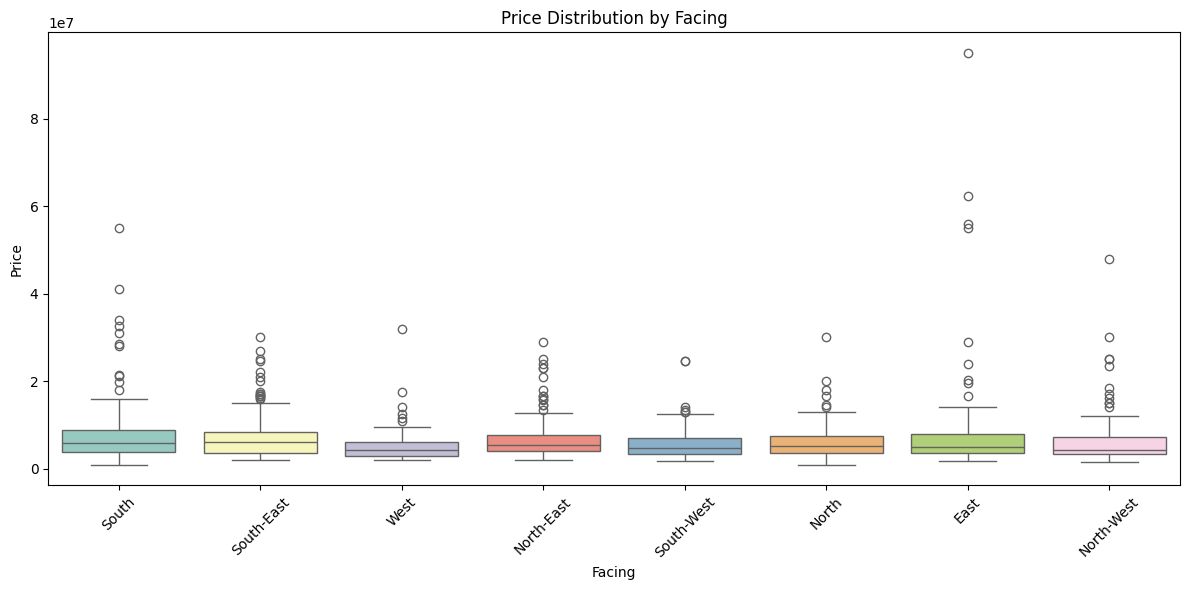

In [269]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

# Drop rows with missing 'Price' or 'Facing'
df_facing = df[~df['Price'].isnull() & ~df['Facing'].isnull()]

# Replace 'Missing' with NaN (optional: you can also drop it later)
df_facing['Facing'] = df_facing['Facing'].replace('Missing', pd.NA)

# OPTIONAL: Drop missing facing
df_facing = df_facing.dropna(subset=['Facing'])

# Plot boxplot of Price by Facing
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_facing, x='Facing', y='Price', palette="Set3")
plt.xticks(rotation=45)
plt.title("Price Distribution by Facing")
plt.tight_layout()
plt.show()


In [270]:
# Group prices by each facing category
groups = [group['Price'].values for name, group in df_facing.groupby('Facing')]

# Run Kruskal-Wallis H-test
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H-statistic: {stat:.2f}, p-value: {p:.4f}")


Kruskal-Wallis H-statistic: 20.26, p-value: 0.0050


In [275]:
df.drop(columns=["Location"], inplace=True)

In [284]:
df.describe

<bound method NDFrame.describe of       BHK       Price    Area  Bathrooms  Balcony  Floor  Total Floors  \
0       3   5000000.0  1059.0          2        2    4.0           4.0   
1       3   7700000.0  2370.0          2        2   14.0          14.0   
2       3   5100000.0  1350.0          2        2    4.0           4.0   
3       2  12500000.0  1175.0          2        0    4.0           5.0   
4       2  12200000.0   879.0          2        2    6.0           9.0   
...   ...         ...     ...        ...      ...    ...           ...   
1134    3   6780000.0  1169.0          2        2    2.0           3.0   
1135    1    946000.0   344.0          1        1    3.0           5.0   
1136    2   2650000.0   895.0          2        1    2.0           4.0   
1137    3   4100000.0  1038.0          2        1    2.0           4.0   
1138    2   3134000.0   814.0          2        1    1.0           4.0   

      Store_Room  Study_Room  Pooja_Room  ...  VisitorParking  Intercom  Park

In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1139 entries, 0 to 1138
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   BHK                    1139 non-null   int64  
 1   Price                  1139 non-null   float64
 2   Area                   1139 non-null   float64
 3   Bathrooms              1139 non-null   int64  
 4   Balcony                1139 non-null   int64  
 5   Floor                  1139 non-null   float64
 6   Total Floors           1139 non-null   float64
 7   Store_Room             1139 non-null   int64  
 8   Study_Room             1139 non-null   int64  
 9   Pooja_Room             1139 non-null   int64  
 10  Servant_Room           1139 non-null   int64  
 11  Others_Room            1139 non-null   int64  
 12  Property_Age_Years     1139 non-null   float64
 13  Area_Type_Encoded      1139 non-null   int64  
 14  Furnishing_Level_Code  1139 non-null   int64  
 15  Faci

In [288]:
floor_median = df['Floor'].median()
total_floors_median = df['Total Floors'].median()

df['Floor'] = df['Floor'].fillna(floor_median)
df['Total Floors'] = df['Total Floors'].fillna(total_floors_median)


In [289]:
df.isnull().sum().sort_values(ascending=False)


BHK                      0
Price                    0
Area                     0
Bathrooms                0
Balcony                  0
Floor                    0
Total Floors             0
Store_Room               0
Study_Room               0
Pooja_Room               0
Servant_Room             0
Others_Room              0
Property_Age_Years       0
Area_Type_Encoded        0
Furnishing_Level_Code    0
Facility_Premium         0
Lift                     0
Maintenance              0
WaterStorage             0
VaastuCompliant          0
FireSecurity             0
VisitorParking           0
Intercom                 0
Park                     0
AiryRooms                0
Gym                      0
Overlook_Pool            0
Overlook_Club            0
LogPrice                 0
Latitude                 0
Longitude                0
dtype: int64

In [291]:
from sklearn.feature_selection import VarianceThreshold

# Remove near-zero variance features (e.g., 95%+ same value)
selector = VarianceThreshold(threshold=0.01)
selector.fit(df.drop(columns=['Price', 'LogPrice']))  # Keep target
low_variance_cols = df.drop(columns=['Price', 'LogPrice']).columns[~selector.get_support()]
print("Low variance columns:", low_variance_cols.tolist())


Low variance columns: ['Others_Room', 'Overlook_Pool', 'Overlook_Club']


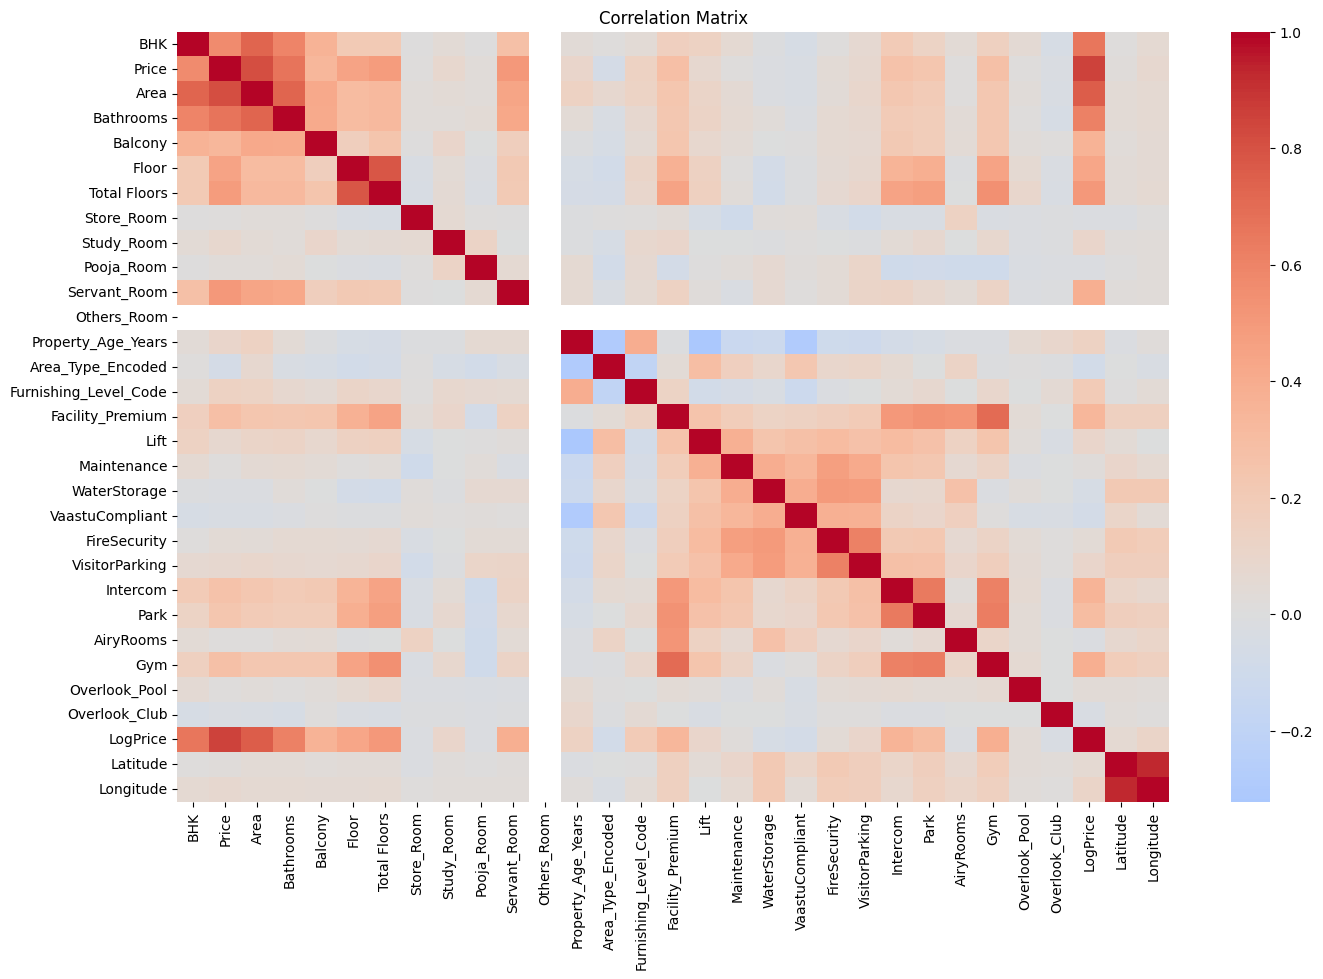

In [292]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
plt.figure(figsize=(16,10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


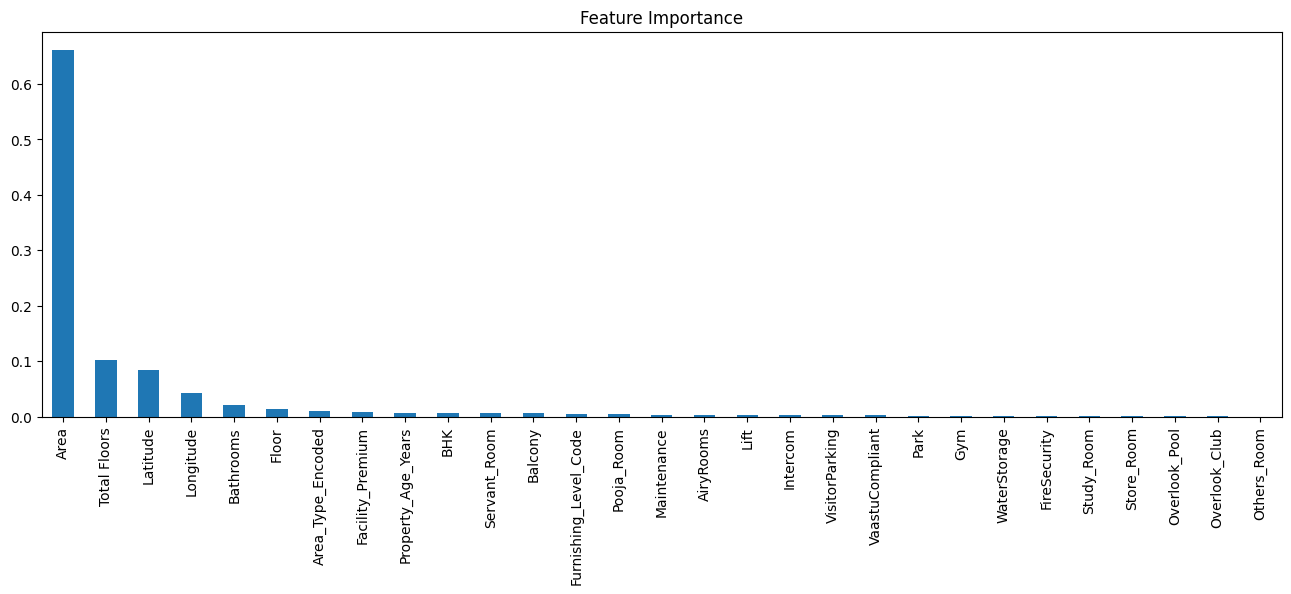

In [293]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=["Price", "LogPrice"])
y = df["LogPrice"]

model = RandomForestRegressor()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(16, 5), title='Feature Importance')
plt.show()

In [295]:
df.to_csv("final_data_for_project.csv", index=False)